In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

In [3]:
dag_path        = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit"
hese_path       = f"{dag_path}/hese/"
globalfit_path  = f"{dag_path}/globalfit/debug_minimizer"
globalfit_hese_path = f"{dag_path}/globalfit_hese"

scan_dir_dict = {
    # --- hese benchmark ---
    "spice_nosyst":           f"{hese_path}/first_try/asimov_SAY_HESEBestfit_NoSystematics_spice",
    "hese_oldpid_nosyst":     f"{hese_path}/first_try/asimov_SAY_HESEBestfit_NoSystematics_ftp_FinalTopology",
    "hese_allfeat_bdtprod_combinedBase":
                              f"{hese_path}/first_try/mcd-simpletopology_flux-hese_feat-11features_plus_"
                              f"rloglmilli_econf_evtgen/"
                              f"bdt1_0.333333_bdt2_0.366667_length_10_"
                              f"10bdtprod_threshold_0.122_combinedBaseline",
    "hese_allfeat_bdtprod_combinedBase_Muon":
                              f"{hese_path}/first_try/mcd-simpletopology_flux-hese_feat-11features_plus_"
                              f"rloglmilli_econf_evtgen/"
                              f"bdt1_0.333333_bdt2_0.366667_length_10_"
                              f"10bdtprod_threshold_0.122_combinedBaseline_Muon",
    "hese_allfeat_bdtprod_combinedBase_newflavorparam_BPL":
                              f"{hese_path}/first_try/mcd-simpletopology_flux-hese_feat-11features_plus_"
                              f"rloglmilli_econf_evtgen/"
                              f"bdt1_0.333333_bdt2_0.366667_length_10_"
                              f"10bdtprod_threshold_0.122_BPL",

    # --- HESE spice ----
    "hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice": f"{hese_path}/spice/hese_HESEBestfit_SPL_noinel_nosyst_Poisson",
    "hese_SPL_noinel_nosyst_Poisson_spice": f"{hese_path}/spice/hese_SPL_noinel_nosyst_Poisson",
    # "hese_BPL_noinel_nosyst_Poisson": f"{hese_path}/spice/hese_BPL_noinel_nosyst_Poisson", # not possible, no fluxless_weight

    # --- HESE ----
    "hese_HESEBestfit_SPL_noinel_nosyst_SAY": f"{hese_path}/SAY/hese_HESEBestfit_SPL_noinel_nosyst",
    "hese_SPL_noinel_nosyst_SAY":             f"{hese_path}/SAY/hese_SPL_noinel_nosyst",
    "hese_BPL_noinel_nosyst_SAY":             f"{hese_path}/SAY/hese_BPL_noinel_nosyst",

    "hese_HESEBestfit_SPL_noinel_nosyst_Poisson": f"{hese_path}/Poisson/hese_HESEBestfit_SPL_noinel_nosyst",
    "hese_SPL_noinel_nosyst_Poisson":             f"{hese_path}/Poisson/hese_SPL_noinel_nosyst",
    "hese_BPL_noinel_nosyst_Poisson":             f"{hese_path}/Poisson/hese_BPL_noinel_nosyst",

    # --- Globalfit ---
    "globalfit_double_SPL_LBFGSB_Poisson":           f"{globalfit_path}/globalfit_double_SPL_LBFGSB_Poisson",
    "globalfit_double_nohese_SPL_LBFGSB_Poisson":           f"{globalfit_path}/globalfit_double_nohese_SPL_LBFGSB_Poisson",

    "globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center":           f"{globalfit_path}/globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center",
    "globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center":           f"{globalfit_path}/globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center",

    

    # --- Globalfit+HESE ---
    "globalfit_double_hese_SPL":             f"{globalfit_hese_path}/globalfit_double_hese_SPL",
    "globalfit_double_hese_BPL_range_philipp_strict":             f"{globalfit_hese_path}/globalfit_double_hese_BPL_range_philipp_strict",
    "globalfit_double_hese_BPL_range_philipp_strict_fine_center":             f"{globalfit_hese_path}/globalfit_double_hese_BPL_range_philipp_strict_fine_center",


}

In [4]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/presentations/2026-03-12_diffuse_update"
os.system(f"mkdir -p {plotting_path}")

0

In [5]:
# load the data
drop_unsuccessful = False
scan_dict = {}
data = {}
for name, scan_dir in scan_dir_dict.items():
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "newflavorparam" in name or "gf" in name:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid=20)


spice_nosyst
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//first_try/asimov_SAY_HESEBestfit_NoSystematics_spice


removed stuff
hese_oldpid_nosyst
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//first_try/asimov_SAY_HESEBestfit_NoSystematics_ftp_FinalTopology
removed stuff
hese_allfeat_bdtprod_combinedBase
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//first_try/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10_10bdtprod_threshold_0.122_combinedBaseline
removed stuff
hese_allfeat_bdtprod_combinedBase_Muon
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//first_try/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10_10bdtprod_threshold_0.122_combinedBaseline_Muon
removed stuff
hese_allfeat_bdtprod_combinedBase_newflavorparam_BPL
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//first_try/mcd-simpletopology_flux-hese_feat-11features_

Lets first compare if my new iteration of HESE matches my previous benchmark. SEEMS FINE

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  level_area = 0.0
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  level_area = 0.0
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  level_area = 0.0
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collecti

Area ratio (hese_allfeat_bdtprod_combinedBase_Muon / hese_allfeat_bdtprod_combinedBase_Muon) at 68%: 1.0000
Area ratio (hese_HESEBestfit_SPL_noinel_nosyst_SAY / hese_allfeat_bdtprod_combinedBase_Muon) at 68%: 0.9708


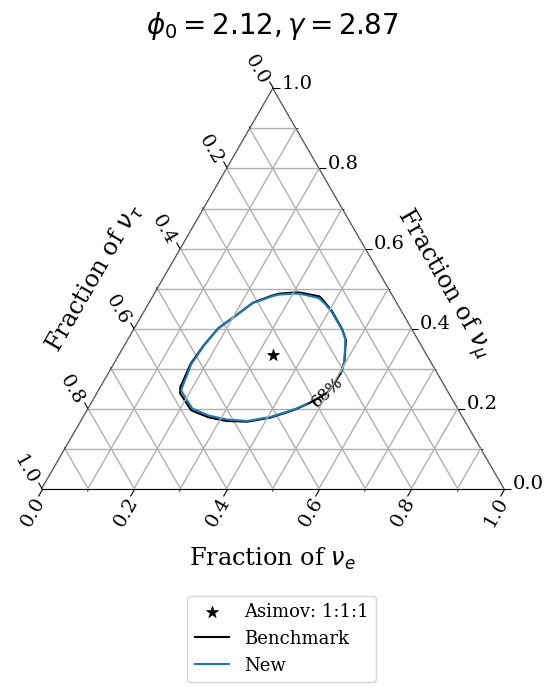

In [ ]:
# compare compare_benchmark_hese_SPL
names = [
"hese_allfeat_bdtprod_combinedBase_Muon",
"hese_HESEBestfit_SPL_noinel_nosyst_SAY"
]
labels = [
    "Benchmark",
    "New"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/compare_benchmark_hese_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_allfeat_bdtprod_combinedBase_Muon", levels=["68%"] )

Area ratio (hese_allfeat_bdtprod_combinedBase_newflavorparam_BPL / hese_allfeat_bdtprod_combinedBase_newflavorparam_BPL) at 68%: 1.0000
Area ratio (hese_BPL_noinel_nosyst_SAY / hese_allfeat_bdtprod_combinedBase_newflavorparam_BPL) at 68%: 1.0358


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  level_area = 0.0
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  level_area = 0.0
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  level_area = 0.0
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  level_area = 0.0


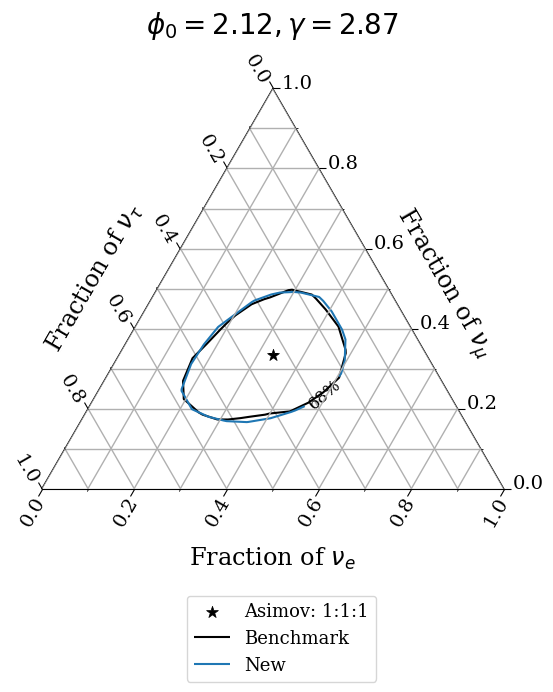

In [20]:
# compare compare_benchmark_hese_SPL
names = [
"hese_allfeat_bdtprod_combinedBase_newflavorparam_BPL",
"hese_BPL_noinel_nosyst_SAY"
]
labels = [
    "Benchmark",
    "New"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/compare_benchmark_hese_BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_allfeat_bdtprod_combinedBase_newflavorparam_BPL", levels=["68%"] )

Area ratio (hese_HESEBestfit_SPL_noinel_nosyst_SAY / hese_HESEBestfit_SPL_noinel_nosyst_SAY) at 68%: 1.0000
Area ratio (hese_SPL_noinel_nosyst_SAY / hese_HESEBestfit_SPL_noinel_nosyst_SAY) at 68%: 0.6919
Area ratio (hese_BPL_noinel_nosyst_SAY / hese_HESEBestfit_SPL_noinel_nosyst_SAY) at 68%: 1.0188


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

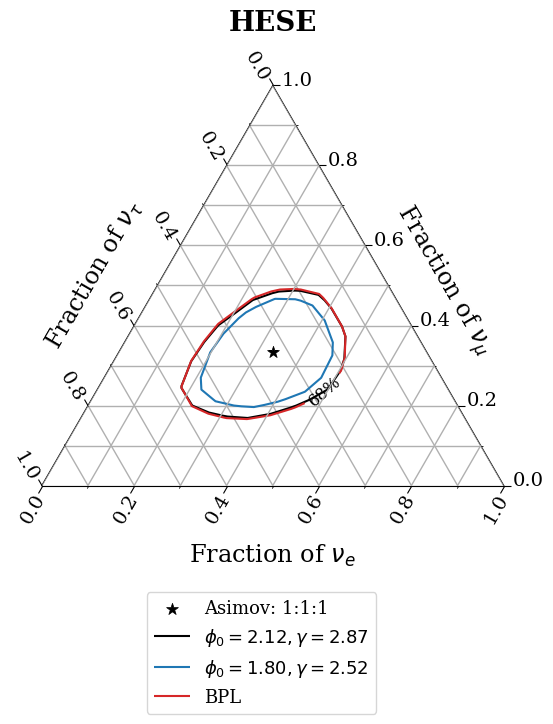

In [ ]:
# compare spectrum hese
names = [
"hese_HESEBestfit_SPL_noinel_nosyst_SAY",
"hese_SPL_noinel_nosyst_SAY",
"hese_BPL_noinel_nosyst_SAY"
]
labels = [
    r"$\phi_0 = 2.12,\gamma=2.87$",
    r"$\phi_0 = 1.80,\gamma=2.52$",
    "BPL"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"HESE",
                  savepath = f"{plotting_path}/compare_spectra_hese.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_HESEBestfit_SPL_noinel_nosyst_SAY", levels=["68%"] )

Area ratio (hese_SPL_noinel_nosyst_SAY / hese_SPL_noinel_nosyst_SAY) at 68%: 1.0000
Area ratio (hese_SPL_noinel_nosyst_Poisson / hese_SPL_noinel_nosyst_SAY) at 68%: 0.9934


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

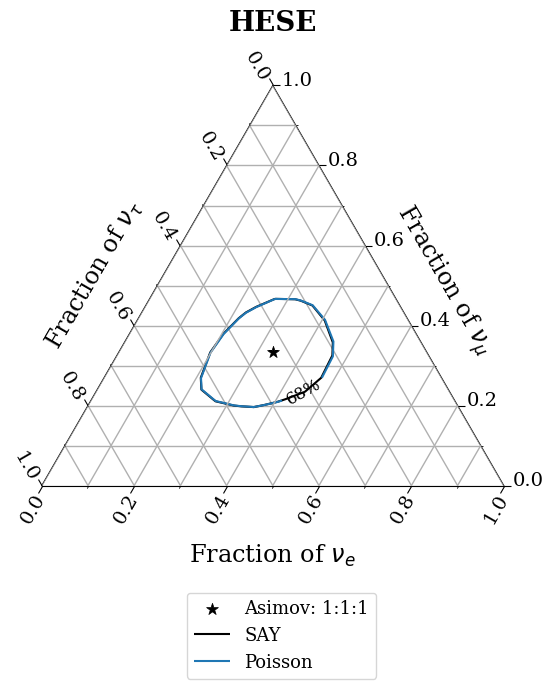

In [30]:
# compare likelihood
names = [
"hese_SPL_noinel_nosyst_SAY",
"hese_SPL_noinel_nosyst_Poisson",
]
labels = [
    "SAY",
    "Poisson",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"HESE",
                  savepath = f"{plotting_path}/compare_likelihood_hese.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_SPL_noinel_nosyst_SAY", levels=["68%"] )

Area ratio (spice_nosyst / spice_nosyst) at 68%: 1.0000
Area ratio (hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice / spice_nosyst) at 68%: 1.1069


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:136: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

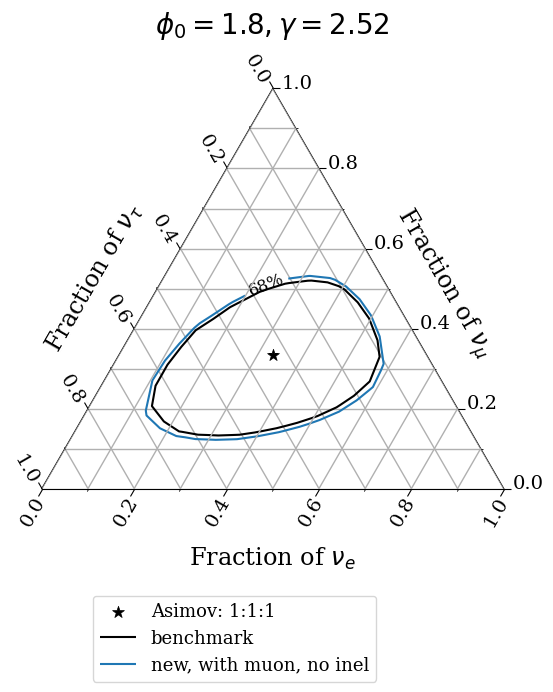

In [9]:
# spice comparison benchmark
names = [
"spice_nosyst",
"hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice",
]
labels = [
    "benchmark",
    "new, with muon, no inel",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1.8,\gamma=2.52$",
                  savepath = f"{plotting_path}/spice_benchmark.png")

for name in names: compare_area( C, alt_key=name, base_key="spice_nosyst", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (hese_SPL_noinel_nosyst_Poisson_spice / hese_SPL_noinel_nosyst_Poisson_spice) at 68%: 1.0000
Area ratio (hese_SPL_noinel_nosyst_Poisson / hese_SPL_noinel_nosyst_Poisson_spice) at 68%: 0.5501
Area ratio (globalfit_double_SPL_LBFGSB_Poisson / hese_SPL_noinel_nosyst_Poisson_spice) at 68%: 0.2159
Area ratio (globalfit_double_nohese_SPL_LBFGSB_Poisson / hese_SPL_noinel_nosyst_Poisson_spice) at 68%: 0.4574
Area ratio (globalfit_double_hese_SPL / hese_SPL_noinel_nosyst_Poisson_spice) at 68%: 0.1206


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:157: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:157: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:157: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:157: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

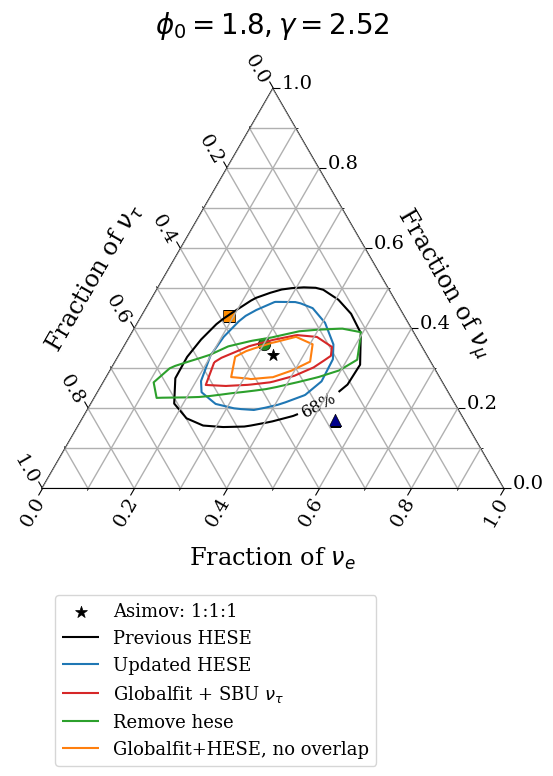

In [16]:
# Moneyplot SPL, with HESE and HESE old
names = [
"hese_SPL_noinel_nosyst_Poisson_spice",
"hese_SPL_noinel_nosyst_Poisson",
"globalfit_double_SPL_LBFGSB_Poisson",
"globalfit_double_nohese_SPL_LBFGSB_Poisson",
"globalfit_double_hese_SPL",
]
labels = [
    "Previous HESE",
    "Updated HESE",
    r"Globalfit + SBU $\nu_\tau$",
    "Remove hese",
    "Globalfit+HESE, no overlap",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1.8,\gamma=2.52$",
                  scenarios=True,
                  savepath = f"{plotting_path}/hese_gfd_gfdnh_gfdnhh_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_SPL_noinel_nosyst_Poisson_spice", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice / hese_BPL_noinel_nosyst_Poisson) at 68%: 1.7803
Area ratio (hese_BPL_noinel_nosyst_Poisson / hese_BPL_noinel_nosyst_Poisson) at 68%: 1.0000
Area ratio (globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center / hese_BPL_noinel_nosyst_Poisson) at 68%: 0.3675
Area ratio (globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center / hese_BPL_noinel_nosyst_Poisson) at 68%: 0.6183
Area ratio (globalfit_double_hese_BPL_range_philipp_strict_fine_center / hese_BPL_noinel_nosyst_Poisson) at 68%: 0.2679


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:157: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:157: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:157: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:157: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

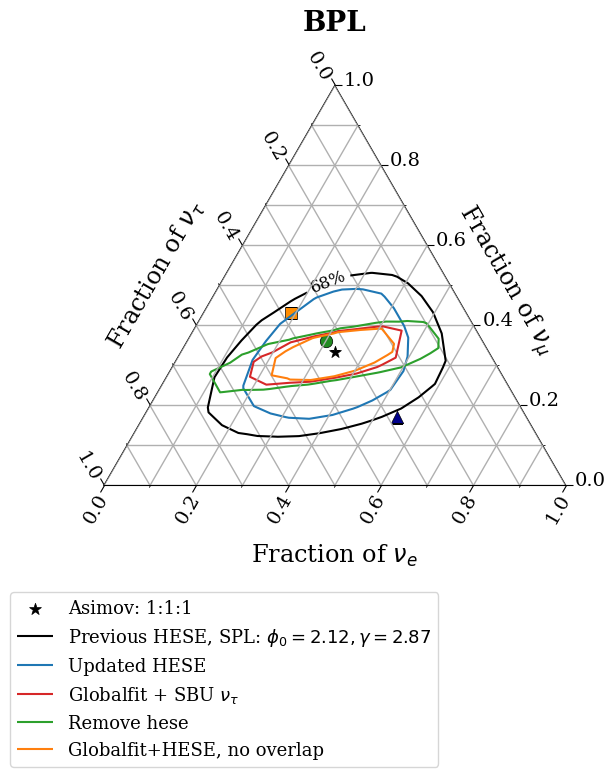

In [15]:
# Moneyplot BPL, with HESE and HESE old
names = [
"hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice",
"hese_BPL_noinel_nosyst_Poisson",
"globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center",
"globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center",
"globalfit_double_hese_BPL_range_philipp_strict_fine_center",
]
labels = [
    r"Previous HESE, SPL: $\phi_0 = 2.12,\gamma=2.87$",
    "Updated HESE",
    r"Globalfit + SBU $\nu_\tau$",
    "Remove hese",
    "Globalfit+HESE, no overlap",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"BPL",
                  scenarios=True,
                  savepath = f"{plotting_path}/hese_gfd_gfdnh_gfdnhh_BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_BPL_noinel_nosyst_Poisson", levels=["68%"] )

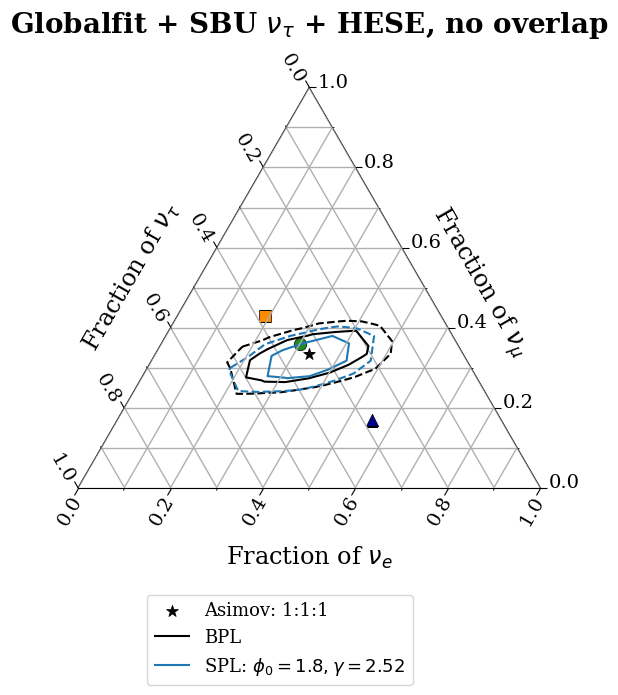

In [19]:
# Moneyplot BPL, with HESE and HESE old
names = [
"globalfit_double_hese_BPL_range_philipp_strict_fine_center",
"globalfit_double_hese_SPL",
]
labels = [
    "BPL",
    r"SPL: $\phi_0 = 1.8,\gamma=2.52$",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%","90%"],
                  title = r"Globalfit + SBU $\nu_\tau$ + HESE, no overlap",
                  scenarios=True,
                  savepath = f"{plotting_path}/globalfit_double_hese_SPL_BPL.png")



Area ratio (hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice / hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice) at 68%: 1.0000
Area ratio (hese_HESEBestfit_SPL_noinel_nosyst_Poisson / hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice) at 68%: 0.5463


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:137: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:137: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:137: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:137: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

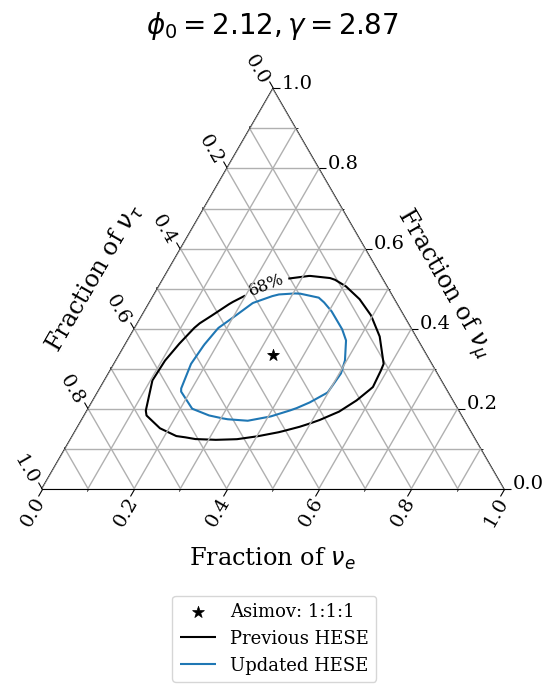

In [19]:
# spice old and new
names = [
"hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice",
"hese_HESEBestfit_SPL_noinel_nosyst_Poisson",
]
labels = [
    "Previous HESE",
    "Updated HESE",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/hese_old_new.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice", levels=["68%"] )